# Atividade I – Bank Marketing
**Machine Learning – ESPM** · Prof. Dr. Antonio Marcos Selmini

André Kalili


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

RS = 42  
sns.set_theme(style='whitegrid')
os.makedirs('figuras', exist_ok=True)
pd.set_option('display.max_columns', 30)

## 1. Análise exploratória
### 1.1 Dimensões, tipos e primeiras linhas

In [2]:
df = pd.read_csv('bank_marketing_completo.csv')
print('Dimensões:', df.shape)
df.head()

Dimensões: (41188, 21)


,idade,profissao,estado_civil,escolaridade,inadimplente,financiamento_imobiliario,emprestimo_pessoal,meio_contato,mes,dia_semana,duracao_ligacao_seg,contatos_campanha_atual,dias_desde_ultimo_contato,contatos_anteriores,resultado_campanha_anterior,taxa_variacao_emprego,indice_precos_consumidor,indice_confianca_consumidor,euribor_3m,numero_empregados,aderiu
0,56,empregado_domestico,casado,fundamental_4anos,nao,nao,nao,telefone_fixo,mai,seg,261,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao
1,57,servicos,casado,ensino_medio,desconhecido,nao,nao,telefone_fixo,mai,seg,149,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao
2,37,servicos,casado,ensino_medio,nao,sim,nao,telefone_fixo,mai,seg,226,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao
3,40,administrativo,casado,fundamental_6anos,nao,nao,nao,telefone_fixo,mai,seg,151,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao
4,56,servicos,casado,ensino_medio,nao,nao,sim,telefone_fixo,mai,seg,307,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   idade                        41188 non-null  int64  
 1   profissao                    41188 non-null  str    
 2   estado_civil                 41188 non-null  str    
 3   escolaridade                 41188 non-null  str    
 4   inadimplente                 41188 non-null  str    
 5   financiamento_imobiliario    41188 non-null  str    
 6   emprestimo_pessoal           41188 non-null  str    
 7   meio_contato                 41188 non-null  str    
 8   mes                          41188 non-null  str    
 9   dia_semana                   41188 non-null  str    
 10  duracao_ligacao_seg          41188 non-null  int64  
 11  contatos_campanha_atual      41188 non-null  int64  
 12  dias_desde_ultimo_contato    41188 non-null  int64  
 13  contatos_anteriores        

In [4]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
idade,41188.0,40.02,10.42,17.00,32.00,38.00,47.00,98.00
duracao_ligacao_seg,41188.0,258.29,259.28,0.00,102.00,180.00,319.00,4918.00
contatos_campanha_atual,41188.0,2.57,2.77,1.00,1.00,2.00,3.00,56.00
dias_desde_ultimo_contato,41188.0,962.48,186.91,0.00,999.00,999.00,999.00,999.00
contatos_anteriores,41188.0,0.17,0.49,0.00,0.00,0.00,0.00,7.00
taxa_variacao_emprego,41188.0,0.08,1.57,-3.40,-1.80,1.10,1.40,1.40
indice_precos_consumidor,41188.0,93.58,0.58,92.20,93.08,93.75,93.99,94.77
indice_confianca_consumidor,41188.0,-40.50,4.63,-50.80,-42.70,-41.80,-36.40,-26.90
euribor_3m,41188.0,3.62,1.73,0.63,1.34,4.86,4.96,5.04
numero_empregados,41188.0,5167.04,72.25,4963.60,5099.10,5191.00,5228.10,5228.10


### 1.2 Qualidade da base
Não há valores nulos de fato, mas a base tem alguns "ausentes disfarçados": a categoria "desconhecido" em várias colunas e o código 999 em "dias_desde_ultimo_contato". Também conferimos duplicatas.

In [5]:
print('Valores nulos:', df.isna().sum().sum())
print('Linhas duplicadas:', df.duplicated().sum())

cat_cols = df.select_dtypes(exclude='number').columns
desc = {c: (df[c] == 'desconhecido').sum() for c in cat_cols if (df[c] == 'desconhecido').any()}
print('\nQuantidade de "desconhecido" por coluna:')
print(pd.Series(desc).sort_values(ascending=False))

print('\n% de 999 em dias_desde_ultimo_contato: {:.1%}'.format((df['dias_desde_ultimo_contato'] == 999).mean()))
print('\ninadimplente:')
print(df['inadimplente'].value_counts())
print('\nLigações com duração 0 s:', (df['duracao_ligacao_seg'] == 0).sum())

Valores nulos: 0
Linhas duplicadas: 12

Quantidade de "desconhecido" por coluna:
inadimplente                 8597
escolaridade                 1731
financiamento_imobiliario     990
emprestimo_pessoal            990
profissao                     330
estado_civil                   80
dtype: int64

% de 999 em dias_desde_ultimo_contato: 96.3%

inadimplente:
inadimplente
nao             32588
desconhecido     8597
sim                 3
Name: count, dtype: int64

Ligações com duração 0 s: 4


### 1.3 Distribuição da variável-alvo
A base é bem desbalanceada: só cerca de 11% dos contatos terminaram em adesão. Isso pesa na escolha da métrica (acurácia sozinha engana).

          qtd  proporcao
aderiu                  
nao     36548     0.8873
sim      4640     0.1127


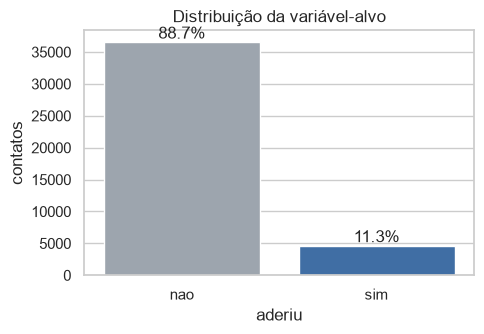

In [6]:
cont = df['aderiu'].value_counts()
prop = df['aderiu'].value_counts(normalize=True)
print(pd.DataFrame({'qtd': cont, 'proporcao': prop.round(4)}))

fig, ax = plt.subplots(figsize=(5, 3.5))
sns.countplot(data=df, x='aderiu', hue='aderiu', order=['nao', 'sim'], palette={'nao': '#9aa5b1', 'sim': '#2f6db5'}, legend=False, ax=ax)
for p, v in zip(ax.patches, prop[['nao', 'sim']]):
    ax.annotate(f'{v:.1%}', (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom')
ax.set_title('Distribuição da variável-alvo')
ax.set_xlabel('aderiu'); ax.set_ylabel('contatos')
plt.tight_layout(); plt.savefig('figuras/fig1_alvo.png', dpi=150); plt.show()

### 1.4 Atributos x adesão
Como a base é desbalanceada, olhar contagem absoluta não ajuda muito. Por isso os gráficos abaixo mostram a **taxa de adesão** dentro de cada grupo. A linha tracejada é a taxa média da base (11,3%).

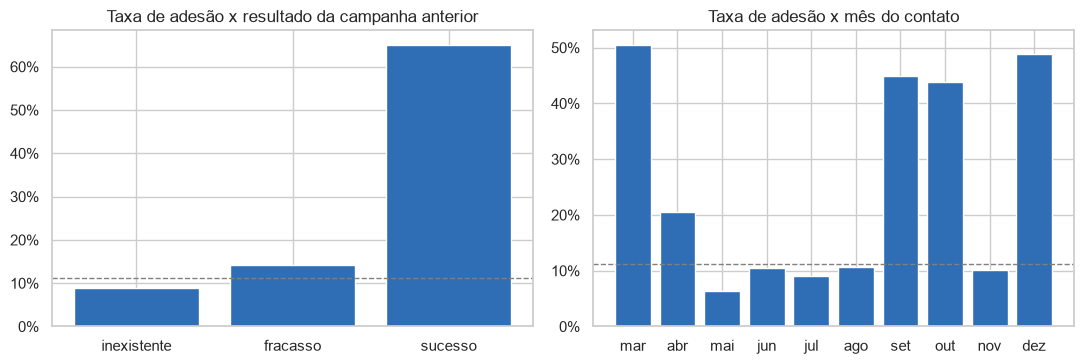

resultado_campanha_anterior
inexistente    0.088
fracasso       0.142
sucesso        0.651
Name: y, dtype: float64
mes
mar    0.505
abr    0.205
mai    0.064
jun    0.105
jul    0.090
ago    0.106
set    0.449
out    0.439
nov    0.101
dez    0.489
Name: y, dtype: float64

Contatos por mês:
mes
mar      546
abr     2632
mai    13769
jun     5318
jul     7174
ago     6178
set      570
out      718
nov     4101
dez      182
Name: count, dtype: int64


In [7]:
df['y'] = (df['aderiu'] == 'sim').astype(int)
taxa_media = df['y'].mean()

def taxa_por(col, ordem=None):
    t = df.groupby(col)['y'].mean()
    return t.reindex(ordem) if ordem is not None else t.sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
t1 = taxa_por('resultado_campanha_anterior', ['inexistente', 'fracasso', 'sucesso'])
axes[0].bar(t1.index, t1.values, color='#2f6db5')
axes[0].set_title('Taxa de adesão x resultado da campanha anterior')
meses = ['mar', 'abr', 'mai', 'jun', 'jul', 'ago', 'set', 'out', 'nov', 'dez']
t2 = taxa_por('mes', meses)
axes[1].bar(t2.index, t2.values, color='#2f6db5')
axes[1].set_title('Taxa de adesão x mês do contato')
for a in axes:
    a.axhline(taxa_media, ls='--', color='gray', lw=1)
    a.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
plt.tight_layout(); plt.savefig('figuras/fig2_historico_mes.png', dpi=150); plt.show()

print(t1.round(3)); print(t2.round(3))
print('\nContatos por mês:'); print(df['mes'].value_counts().reindex(meses))

A Euribor e o número de empregados são indicadores do momento do contato. A diferença entre quem aderiu e quem não aderiu é grande, o que confirma o comentário do enunciado sobre o peso do contexto macroeconômico.

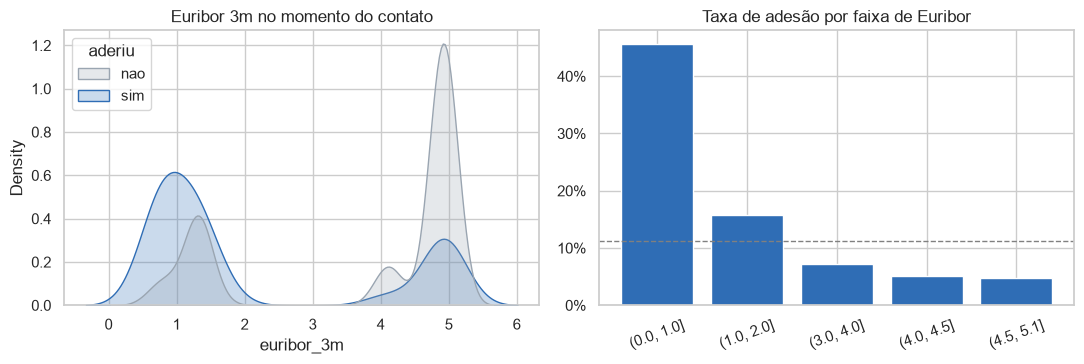

euribor_3m
(0.0, 1.0]    0.457
(1.0, 2.0]    0.158
(3.0, 4.0]    0.071
(4.0, 4.5]    0.050
(4.5, 5.1]    0.048
Name: y, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
sns.kdeplot(data=df, x='euribor_3m', hue='aderiu', common_norm=False, fill=True,
            palette={'nao': '#9aa5b1', 'sim': '#2f6db5'}, ax=axes[0])
axes[0].set_title('Euribor 3m no momento do contato')

faixas = pd.cut(df['euribor_3m'], bins=[0, 1, 2, 3, 4, 4.5, 5.1])
t3 = df.groupby(faixas, observed=True)['y'].mean()
axes[1].bar(t3.index.astype(str), t3.values, color='#2f6db5')
axes[1].axhline(taxa_media, ls='--', color='gray', lw=1)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
axes[1].set_title('Taxa de adesão por faixa de Euribor')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.savefig('figuras/fig3_euribor.png', dpi=150); plt.show()
print(t3.round(3))

A duração da ligação é, de longe, o atributo que mais separa as classes. O problema é que ela só existe **depois** que a ligação termina (voltamos nisso na seção 2.3).

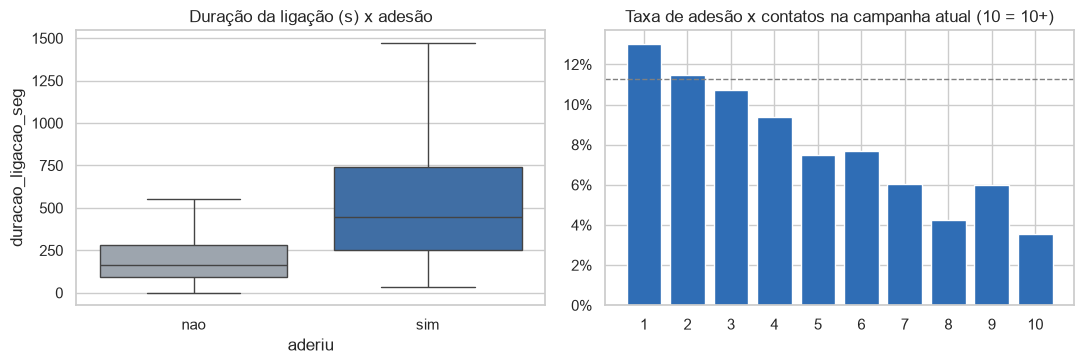

aderiu
nao    163.5
sim    449.0
Name: duracao_ligacao_seg, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
sns.boxplot(data=df, x='aderiu', y='duracao_ligacao_seg', hue='aderiu', order=['nao', 'sim'],
            palette={'nao': '#9aa5b1', 'sim': '#2f6db5'}, legend=False, showfliers=False, ax=axes[0])
axes[0].set_title('Duração da ligação (s) x adesão')

t4 = df.groupby(df['contatos_campanha_atual'].clip(upper=10))['y'].mean()
axes[1].bar(t4.index.astype(str), t4.values, color='#2f6db5')
axes[1].axhline(taxa_media, ls='--', color='gray', lw=1)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
axes[1].set_title('Taxa de adesão x contatos na campanha atual (10 = 10+)')
plt.tight_layout(); plt.savefig('figuras/fig4_duracao_contatos.png', dpi=150); plt.show()

print(df.groupby('aderiu')['duracao_ligacao_seg'].median())

Por fim, a correlação entre os atributos numéricos. Os indicadores macro andam praticamente juntos (Euribor, número de empregados e variação do emprego passam de 0,9), o que vai importar na hora de interpretar os coeficientes da regressão logística.

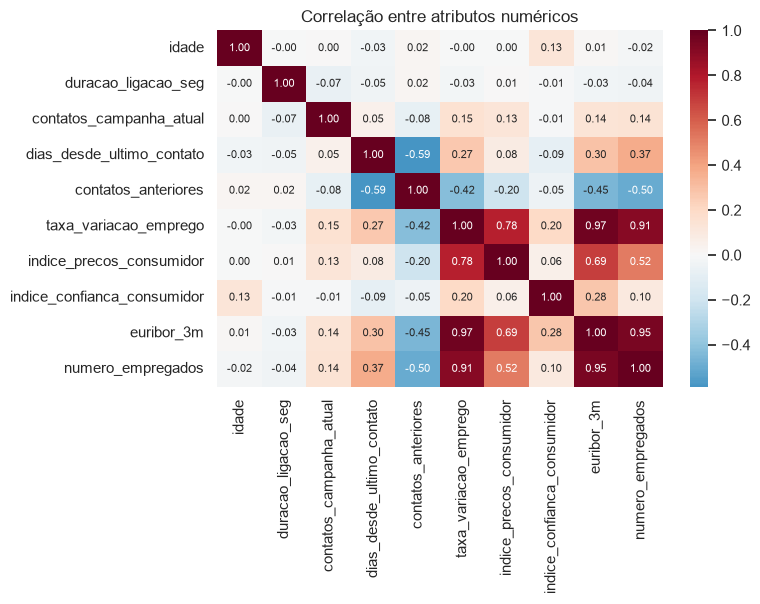

In [10]:
num_cols_all = df.select_dtypes('number').columns.drop('y')
fig, ax = plt.subplots(figsize=(8, 6.2))
sns.heatmap(df[num_cols_all].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Correlação entre atributos numéricos')
plt.tight_layout(); plt.savefig('figuras/fig5_correlacao.png', dpi=150); plt.show()

**Resumo do que a EDA mostrou e que precisa de tratamento:**
- alvo desbalanceado (≈ 11% de "sim"): acurácia não serve como critério e a divisão treino/teste precisa ser estratificada;
- 12 linhas duplicadas;
- "dias_desde_ultimo_contato" usa 999 como código de "nunca contatado" (96% da coluna). Se entrar como número, o 999 distorce a escala do k-NN e da logística;
- categorias "desconhecido" em seis colunas. Em "inadimplente" são cerca de 21% das linhas, e "sim" aparece só 3 vezes;
- atributos categóricos em texto, que precisam virar números para os três modelos;
- escalas muito diferentes entre os numéricos (idade, Euribor, número de empregados...), o que afeta o k-NN diretamente;
- "duracao_ligacao_seg" (e, em menor grau, "contatos_campanha_atual") só são conhecidos depois do contato;
- indicadores macro muito correlacionados entre si.

## 2. Preparação dos dados
### 2.1 Alterações feitas antes da divisão
São transformações linha a linha, que não usam nenhuma estatística da base (média, desvio etc.). Por isso podem ser feitas antes do "train_test_split" sem risco de vazamento.

In [11]:
dados = df.drop(columns='y').copy()

# 1) duplicatas: removemos para que a mesma linha não caia ao mesmo tempo no treino e no teste
antes = len(dados)
dados = dados.drop_duplicates().reset_index(drop=True)
print('Duplicatas removidas:', antes - len(dados), '| linhas restantes:', len(dados))

# 2) 999 em dias_desde_ultimo_contato: viramos um indicador 0/1 e descartamos a coluna original
dados['contatado_antes'] = (dados['dias_desde_ultimo_contato'] != 999).astype(int)
dados = dados.drop(columns='dias_desde_ultimo_contato')

# 3) alvo em 0/1 (classe positiva = sim)
y = (dados.pop('aderiu') == 'sim').astype(int)
X = dados
print(X.shape, y.mean().round(4))

Duplicatas removidas: 12 | linhas restantes: 41176
(41176, 20) 0.1127


### 2.2 Divisão treino/teste
30% para teste, estratificado pelo alvo e com "random_state=42". A divisão é feita **uma vez só**, com todas as colunas. Os dois cenários usam exatamente as mesmas linhas de treino e de teste, mudando apenas as colunas.

In [12]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RS)
print('Treino:', X_treino.shape, '| % sim: {:.2%}'.format(y_treino.mean()))
print('Teste :', X_teste.shape, '| % sim: {:.2%}'.format(y_teste.mean()))

Treino: (28823, 20) | % sim: 11.27%
Teste : (12353, 20) | % sim: 11.27%


### 2.3 Os dois cenários
O modelo seria usado **antes** de o operador ligar. Nesse momento:
- `duracao_ligacao_seg` não existe, porque só se sabe quanto a ligação durou quando ela acaba. Além disso, ela está ligada ao próprio resultado (quem aceita fica mais tempo na linha, e uma ligação de 0 s é sempre "não");
- `contatos_campanha_atual` é o total de ligações feitas ao cliente na campanha **contando a última**. É um número fechado só no fim da campanha, e quando o banco monta a lista de prioridades ainda não sabe quantas ligações vão ser necessárias.

Os outros atributos são conhecidos antes da ligação: dados cadastrais, histórico de campanhas anteriores, o canal (celular ou fixo), a data planejada e os indicadores econômicos do dia.

In [13]:
pos_contato = ['duracao_ligacao_seg', 'contatos_campanha_atual']

cat_cols = X.select_dtypes(exclude='number').columns.tolist()
num_completo = X.select_dtypes('number').columns.tolist()
num_principal = [c for c in num_completo if c not in pos_contato]

cenarios = {
    'principal': {'num': num_principal, 'cat': cat_cols},
    'completo':  {'num': num_completo,  'cat': cat_cols},
}
for nome, cols in cenarios.items():
    print(f"{nome}: {len(cols['num'])} numéricos + {len(cols['cat'])} categóricos")
print('Excluídos no principal:', pos_contato)

principal: 8 numéricos + 10 categóricos
completo: 10 numéricos + 10 categóricos
Excluídos no principal: ['duracao_ligacao_seg', 'contatos_campanha_atual']


### 2.4 Pré-processamento dentro do Pipeline
- **Numéricos**: `StandardScaler` (média 0, desvio 1). É indispensável para o k-NN, que mede distância, e deixa os coeficientes da logística comparáveis entre si.
- **Categóricos**: `OneHotEncoder`. A categoria `desconhecido` foi mantida como uma categoria própria, e não imputada, porque ela carrega informação (por exemplo, quem tem `inadimplente = desconhecido` adere menos). `handle_unknown='ignore'` evita erro caso alguma categoria rara (como `inadimplente = sim`, com 3 linhas) não apareça em alguma dobra.

Como tudo fica dentro do `Pipeline`, o `fit` do scaler e do encoder só enxerga o treino (ou a dobra de treino, na validação cruzada).

In [14]:
def preprocessador(cenario):
    cols = cenarios[cenario]
    return ColumnTransformer([
        ('num', StandardScaler(), cols['num']),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cols['cat']),
    ])

def montar(cenario, modelo):
    return Pipeline([('prep', preprocessador(cenario)), ('modelo', modelo)])

# quantas colunas saem do pré-processamento em cada cenário
for c in cenarios:
    print(c, preprocessador(c).fit(X_treino).transform(X_treino.head()).shape[1], 'colunas')

principal 61 colunas
completo 63 colunas


## 3. Modelagem
### 3.1 Métrica usada nas escolhas
Usamos o **F1 da classe positiva (`sim`)** para escolher hiperparâmetros e comparar modelos. A justificativa completa está no relatório. Em resumo: um modelo que responde "não" para todo mundo já tem 88,7% de acurácia, então a acurácia não diferencia nada. O F1 combina a precisão (ligações desperdiçadas) e o recall (clientes interessados que ficariam de fora).

### 3.2 Busca de hiperparâmetros com validação cruzada
Por causa do custo do k-NN, a busca (`GridSearchCV`, 5 dobras estratificadas) é feita numa **amostra estratificada de 10.000 linhas do treino**. O conjunto de teste não participa de nada aqui. Depois de escolher, cada modelo é treinado de novo no treino completo.

In [15]:
X_busca, _, y_busca, _ = train_test_split(X_treino, y_treino, train_size=10000,
                                          stratify=y_treino, random_state=RS)
print('Amostra de busca:', X_busca.shape, '| % sim: {:.2%}'.format(y_busca.mean()))

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RS)

grades = {
    'kNN': (KNeighborsClassifier(),
            {'modelo__n_neighbors': [1, 3, 5, 7, 9, 11, 15, 21, 31, 41],
             'modelo__weights': ['uniform', 'distance']}),
    'NB Gaussiano': (GaussianNB(),
            {'modelo__var_smoothing': [1e-9, 1e-6, 1e-3, 1e-2, 1e-1]}),
    'NB Bernoulli': (BernoulliNB(),
            {'modelo__alpha': [0.01, 0.1, 1.0, 10.0]}),
    'Reg. Logística': (LogisticRegression(max_iter=1000, random_state=RS),
            {'modelo__C': [0.001, 0.01, 0.1, 1, 10, 100],
             'modelo__class_weight': [None, 'balanced']}),
}

Amostra de busca: (10000, 20) | % sim: 11.27%


In [16]:
melhores = {}   # (cenario, modelo) -> parâmetros escolhidos
resumo_busca = []
for cen in cenarios:
    for nome, (modelo, grade) in grades.items():
        busca = GridSearchCV(montar(cen, modelo), grade, cv=cv5, scoring='f1', n_jobs=-1)
        busca.fit(X_busca, y_busca)
        melhores[(cen, nome)] = busca.best_params_
        resumo_busca.append({'cenário': cen, 'modelo': nome,
                             'melhores parâmetros': {k.replace('modelo__', ''): v for k, v in busca.best_params_.items()},
                             'F1 médio (CV, amostra)': round(busca.best_score_, 4)})
        if nome == 'kNN' and cen == 'principal':
            res_knn = pd.DataFrame(busca.cv_results_)

pd.DataFrame(resumo_busca)

,cenário,modelo,melhores parâmetros,"F1 médio (CV, amostra)"
0,principal,kNN,"{'n_neighbors': 11, 'weights': 'uniform'}",0.3569
1,principal,NB Gaussiano,{'var_smoothing': 0.001},0.4303
2,principal,NB Bernoulli,{'alpha': 10.0},0.4101
3,principal,Reg. Logística,"{'C': 1, 'class_weight': 'balanced'}",0.4622
4,completo,kNN,"{'n_neighbors': 9, 'weights': 'uniform'}",0.4669
5,completo,NB Gaussiano,{'var_smoothing': 0.01},0.4703
6,completo,NB Bernoulli,{'alpha': 10.0},0.4398
7,completo,Reg. Logística,"{'C': 100, 'class_weight': 'balanced'}",0.5792


Curva do F1 em função de k (cenário principal). Ajuda a enxergar que a escolha não foi um pico isolado.

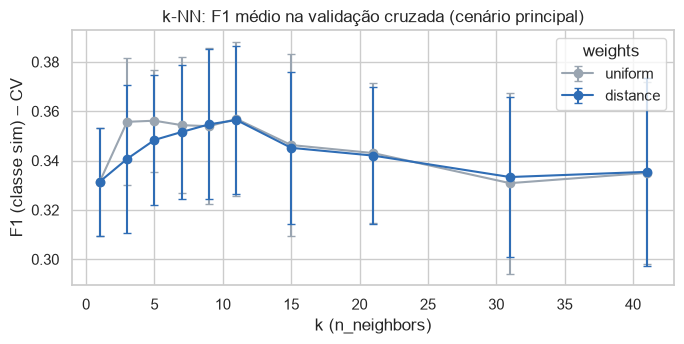

In [17]:
fig, ax = plt.subplots(figsize=(7, 3.6))
for w, cor in [('uniform', '#9aa5b1'), ('distance', '#2f6db5')]:
    r = res_knn[res_knn['param_modelo__weights'] == w].sort_values('param_modelo__n_neighbors')
    ax.errorbar(r['param_modelo__n_neighbors'], r['mean_test_score'], yerr=r['std_test_score'],
                marker='o', capsize=3, label=w, color=cor)
ax.set_xlabel('k (n_neighbors)'); ax.set_ylabel('F1 (classe sim) – CV')
ax.set_title('k-NN: F1 médio na validação cruzada (cenário principal)')
ax.legend(title='weights')
plt.tight_layout(); plt.savefig('figuras/fig6_knn_k.png', dpi=150); plt.show()

### 3.3 Qual Naive Bayes usar?
Depois do one-hot, a maior parte das colunas vira 0/1 (53 das 61 no cenário principal), e isso puxa para o **BernoulliNB**, que modela justamente presença ou ausência. O ponto fraco dele aqui é que as 8 colunas numéricas também são binarizadas (o corte padrão é 0, ou seja, acima ou abaixo da média depois da padronização). Com isso, os indicadores macro, que são os mais informativos, perdem quase toda a nuance.

O **GaussianNB** faz o caminho oposto: trata bem os numéricos contínuos, mas supõe uma curva normal até para as dummies, o que não faz sentido. Como nenhum dos dois é perfeito para uma base mista, testamos os dois e ficamos com o maior F1 na validação cruzada.

In [18]:
nb_escolhido = {}
for cen in cenarios:
    f1_g = [r['F1 médio (CV, amostra)'] for r in resumo_busca if r['cenário'] == cen and r['modelo'] == 'NB Gaussiano'][0]
    f1_b = [r['F1 médio (CV, amostra)'] for r in resumo_busca if r['cenário'] == cen and r['modelo'] == 'NB Bernoulli'][0]
    nb_escolhido[cen] = 'NB Bernoulli' if f1_b >= f1_g else 'NB Gaussiano'
    print(f'{cen}: Gaussiano F1={f1_g:.4f} | Bernoulli F1={f1_b:.4f} -> {nb_escolhido[cen]}')

principal: Gaussiano F1=0.4303 | Bernoulli F1=0.4101 -> NB Gaussiano
completo: Gaussiano F1=0.4703 | Bernoulli F1=0.4398 -> NB Gaussiano


### 3.4 Treino final no conjunto de treino completo
Com os hiperparâmetros definidos, cada pipeline é treinado novamente usando as 28.823 linhas de treino.

In [19]:
base_modelos = {'kNN': KNeighborsClassifier, 'NB Gaussiano': GaussianNB, 'NB Bernoulli': BernoulliNB,
                'Reg. Logística': lambda **p: LogisticRegression(max_iter=1000, random_state=RS, **p)}

def modelo_final(cen, nome):
    params = {k.replace('modelo__', ''): v for k, v in melhores[(cen, nome)].items()}
    return montar(cen, base_modelos[nome](**params))

finais = {}
for cen in cenarios:
    for nome in grades:
        finais[(cen, nome)] = modelo_final(cen, nome).fit(X_treino, y_treino)
print('Modelos treinados:', len(finais))

Modelos treinados: 8


## 4. Avaliação
### 4.1 Métricas no conjunto de teste
É a primeira e única vez que o teste é usado. Avaliamos os quatro modelos (as duas variantes de NB entram para comparação) nos dois cenários. A AUC entra como complemento, porque mede a qualidade do ranking de probabilidades, que é justamente o uso pretendido (priorizar a fila de ligações).

In [20]:
linhas = []
preds = {}
for (cen, nome), pipe in finais.items():
    p = pipe.predict(X_teste)
    proba = pipe.predict_proba(X_teste)[:, 1]
    preds[(cen, nome)] = p
    linhas.append({'cenário': cen, 'modelo': nome,
                   'acurácia': accuracy_score(y_teste, p),
                   'precisão (sim)': precision_score(y_teste, p),
                   'recall (sim)': recall_score(y_teste, p),
                   'F1 (sim)': f1_score(y_teste, p),
                   'precisão (não)': precision_score(y_teste, p, pos_label=0),
                   'recall (não)': recall_score(y_teste, p, pos_label=0),
                   'F1 (não)': f1_score(y_teste, p, pos_label=0),
                   'AUC': roc_auc_score(y_teste, proba)})
teste = pd.DataFrame(linhas)
teste.round(3)

,cenário,modelo,acurácia,precisão (sim),recall (sim),F1 (sim),precisão (não),recall (não),F1 (não),AUC
0,principal,kNN,0.896,0.587,0.259,0.359,0.912,0.977,0.943,0.759
1,principal,NB Gaussiano,0.863,0.406,0.468,0.435,0.931,0.913,0.922,0.779
2,principal,NB Bernoulli,0.804,0.314,0.621,0.417,0.945,0.827,0.882,0.778
3,principal,Reg. Logística,0.833,0.364,0.644,0.465,0.950,0.857,0.901,0.803
4,completo,kNN,0.904,0.611,0.395,0.480,0.926,0.968,0.947,0.897
5,completo,NB Gaussiano,0.866,0.425,0.550,0.480,0.941,0.906,0.923,0.847
6,completo,NB Bernoulli,0.822,0.345,0.642,0.448,0.949,0.845,0.894,0.820
7,completo,Reg. Logística,0.863,0.447,0.894,0.596,0.985,0.859,0.918,0.938


Relatório por classe (`classification_report`) de cada modelo, para conferência:

In [21]:
for (cen, nome), p in preds.items():
    print(f'===== {cen} | {nome} =====')
    print(classification_report(y_teste, p, target_names=['nao', 'sim'], digits=3))

===== principal | kNN =====
              precision    recall  f1-score   support

         nao      0.912     0.977     0.943     10961
         sim      0.587     0.259     0.359      1392

    accuracy                          0.896     12353
   macro avg      0.750     0.618     0.651     12353
weighted avg      0.875     0.896     0.878     12353

===== principal | NB Gaussiano =====
              precision    recall  f1-score   support

         nao      0.931     0.913     0.922     10961
         sim      0.406     0.468     0.435      1392

    accuracy                          0.863     12353
   macro avg      0.669     0.691     0.678     12353
weighted avg      0.872     0.863     0.867     12353

===== principal | NB Bernoulli =====
              precision    recall  f1-score   support

         nao      0.945     0.827     0.882     10961
         sim      0.314     0.621     0.417      1392

    accuracy                          0.804     12353
   macro avg      0.629   

### 4.2 Matrizes de confusão

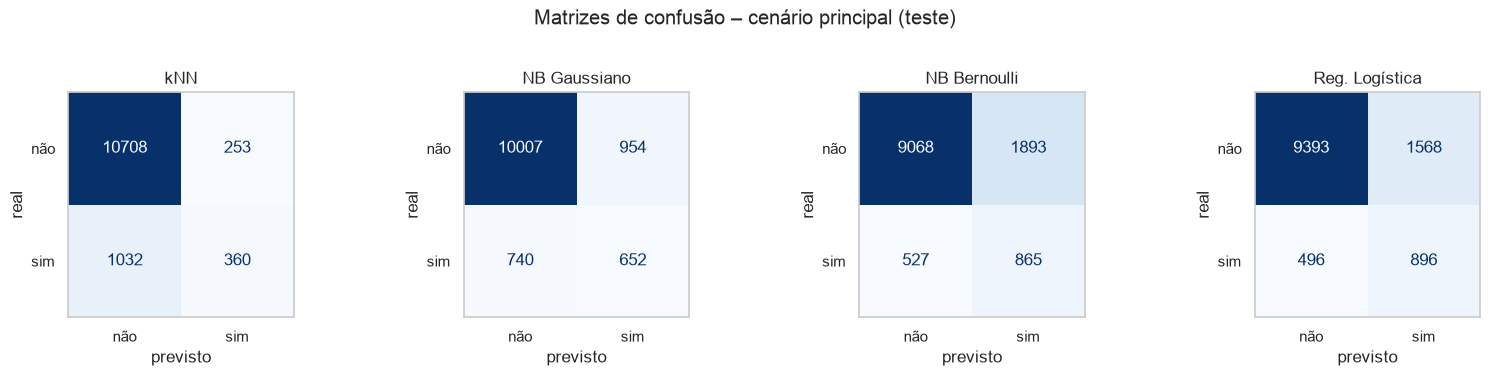

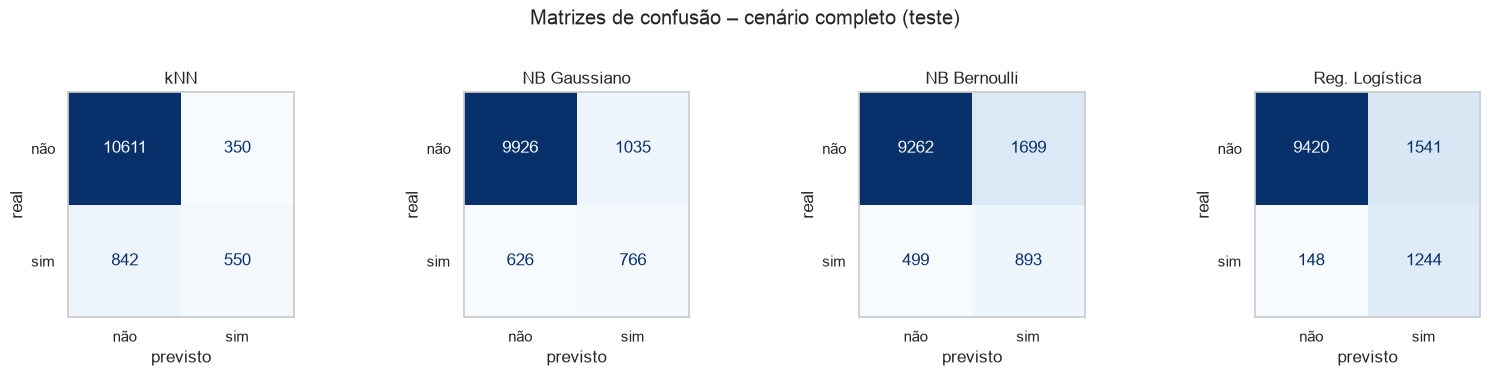

In [22]:
for cen in cenarios:
    fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
    for ax, nome in zip(axes, grades):
        cm = confusion_matrix(y_teste, preds[(cen, nome)])
        ConfusionMatrixDisplay(cm, display_labels=['não', 'sim']).plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
        ax.set_title(nome); ax.grid(False)
        ax.set_xlabel('previsto'); ax.set_ylabel('real')
    fig.suptitle(f'Matrizes de confusão – cenário {cen} (teste)', y=1.03)
    plt.tight_layout(); plt.savefig(f'figuras/fig7_cm_{cen}.png', dpi=150, bbox_inches='tight'); plt.show()

Os mesmos números em forma de tabela, junto com uma leitura de negócio: se o banco ligasse só para quem o modelo marca como "sim", quantas ligações faria e que parte das adesões conseguiria captar.

In [23]:
erros = []
for (cen, nome), p in preds.items():
    vn, fp, fn, vp = confusion_matrix(y_teste, p).ravel()
    erros.append({'cenário': cen, 'modelo': nome, 'VP': vp, 'FP': fp, 'FN': fn, 'VN': vn,
                  'ligações (VP+FP)': vp + fp,
                  '% das ligações que convertem': vp / (vp + fp),
                  '% das adesões captadas': vp / (vp + fn)})
erros = pd.DataFrame(erros)
print('Referência: ligar para todos os', len(y_teste), 'clientes do teste converte {:.1%}'.format(y_teste.mean()))
erros.round(3)

Referência: ligar para todos os 12353 clientes do teste converte 11.3%


,cenário,modelo,VP,FP,FN,VN,ligações (VP+FP),% das ligações que convertem,% das adesões captadas
0,principal,kNN,360,253,1032,10708,613,0.587,0.259
1,principal,NB Gaussiano,652,954,740,10007,1606,0.406,0.468
2,principal,NB Bernoulli,865,1893,527,9068,2758,0.314,0.621
3,principal,Reg. Logística,896,1568,496,9393,2464,0.364,0.644
4,completo,kNN,550,350,842,10611,900,0.611,0.395
5,completo,NB Gaussiano,766,1035,626,9926,1801,0.425,0.550
6,completo,NB Bernoulli,893,1699,499,9262,2592,0.345,0.642
7,completo,Reg. Logística,1244,1541,148,9420,2785,0.447,0.894


### 4.3 Validação cruzada estratificada (5 dobras) no treino completo
Média e desvio do F1 (classe sim) para cada modelo, com os hiperparâmetros escolhidos. Fizemos para os dois cenários, mas o enunciado pede principalmente o principal.

In [24]:
cv_linhas = []
for (cen, nome) in finais:
    notas = cross_val_score(modelo_final(cen, nome), X_treino, y_treino, cv=cv5, scoring='f1', n_jobs=-1)
    cv_linhas.append({'cenário': cen, 'modelo': nome, 'F1 CV média': notas.mean(), 'F1 CV desvio': notas.std()})
cv_df = pd.DataFrame(cv_linhas)
cv_df.round(4)

,cenário,modelo,F1 CV média,F1 CV desvio
0,principal,kNN,0.3696,0.0155
1,principal,NB Gaussiano,0.4185,0.0152
2,principal,NB Bernoulli,0.3996,0.0145
3,principal,Reg. Logística,0.4456,0.0137
4,completo,kNN,0.4869,0.0113
5,completo,NB Gaussiano,0.4655,0.0119
6,completo,NB Bernoulli,0.4394,0.0140
7,completo,Reg. Logística,0.5866,0.0068


### 4.4 Tabela comparativa consolidada

In [25]:
param_txt = {k: ', '.join(f"{p.replace('modelo__', '')}={v}" for p, v in d.items()) for k, d in melhores.items()}
tabela = teste.merge(cv_df, on=['cenário', 'modelo'])
tabela.insert(2, 'hiperparâmetros', [param_txt[(c, m)] for c, m in zip(tabela['cenário'], tabela['modelo'])])
tabela['F1 CV (média ± dp)'] = tabela.apply(lambda r: f"{r['F1 CV média']:.3f} ± {r['F1 CV desvio']:.3f}", axis=1)
cols_tab = ['cenário', 'modelo', 'hiperparâmetros', 'acurácia', 'precisão (sim)', 'recall (sim)', 'F1 (sim)',
            'F1 (não)', 'AUC', 'F1 CV (média ± dp)']
tabela = tabela[cols_tab]
tabela.round(3)

,cenário,modelo,hiperparâmetros,acurácia,precisão (sim),recall (sim),F1 (sim),F1 (não),AUC,F1 CV (média ± dp)
0,principal,kNN,"n_neighbors=11, weights=uniform",0.896,0.587,0.259,0.359,0.943,0.759,0.370 ± 0.015
1,principal,NB Gaussiano,var_smoothing=0.001,0.863,0.406,0.468,0.435,0.922,0.779,0.419 ± 0.015
2,principal,NB Bernoulli,alpha=10.0,0.804,0.314,0.621,0.417,0.882,0.778,0.400 ± 0.014
3,principal,Reg. Logística,"C=1, class_weight=balanced",0.833,0.364,0.644,0.465,0.901,0.803,0.446 ± 0.014
4,completo,kNN,"n_neighbors=9, weights=uniform",0.904,0.611,0.395,0.480,0.947,0.897,0.487 ± 0.011
5,completo,NB Gaussiano,var_smoothing=0.01,0.866,0.425,0.550,0.480,0.923,0.847,0.465 ± 0.012
6,completo,NB Bernoulli,alpha=10.0,0.822,0.345,0.642,0.448,0.894,0.820,0.439 ± 0.014
7,completo,Reg. Logística,"C=100, class_weight=balanced",0.863,0.447,0.894,0.596,0.918,0.938,0.587 ± 0.007


Visualização rápida do F1 (sim) no teste, comparando os dois cenários:

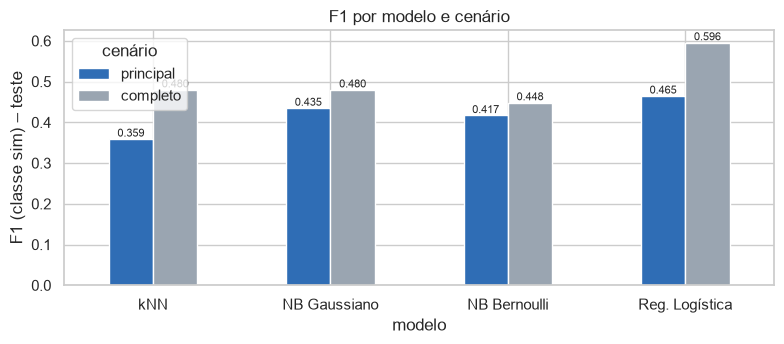

In [26]:
fig, ax = plt.subplots(figsize=(8, 3.6))
piv = teste.pivot(index='modelo', columns='cenário', values='F1 (sim)').loc[list(grades)]
piv[['principal', 'completo']].plot(kind='bar', ax=ax, color=['#2f6db5', '#9aa5b1'], rot=0)
ax.set_ylabel('F1 (classe sim) – teste'); ax.set_title('F1 por modelo e cenário')
for cont in ax.containers:
    ax.bar_label(cont, fmt='%.3f', fontsize=8)
plt.tight_layout(); plt.savefig('figuras/fig8_cenarios.png', dpi=150); plt.show()

### 4.5 Interpretação da regressão logística (cenário principal)
Como os numéricos estão padronizados, cada coeficiente numérico representa o efeito de **um desvio-padrão** a mais. Nas dummies, o efeito é o de pertencer àquela categoria. `exp(coef)` é o fator que multiplica a chance (odds) de adesão.

In [27]:
lr = finais[('principal', 'Reg. Logística')]
nomes = lr.named_steps['prep'].get_feature_names_out()
coefs = pd.DataFrame({'atributo': nomes, 'coef': lr.named_steps['modelo'].coef_[0]})
coefs['odds_ratio'] = np.exp(coefs['coef'])
coefs['|coef|'] = coefs['coef'].abs()
top5 = coefs.sort_values('|coef|', ascending=False).head(5)
print('Intercepto:', lr.named_steps['modelo'].intercept_.round(3))
top5.round(3)

Intercepto: [-0.024]


,atributo,coef,odds_ratio,|coef|
2,num__taxa_variacao_emprego,-2.224,0.108,2.224
49,cat__mes_mar,1.260,3.527,1.260
3,num__indice_precos_consumidor,0.994,2.703,0.994
5,num__euribor_3m,0.760,2.138,0.760
47,cat__mes_jun,-0.728,0.483,0.728


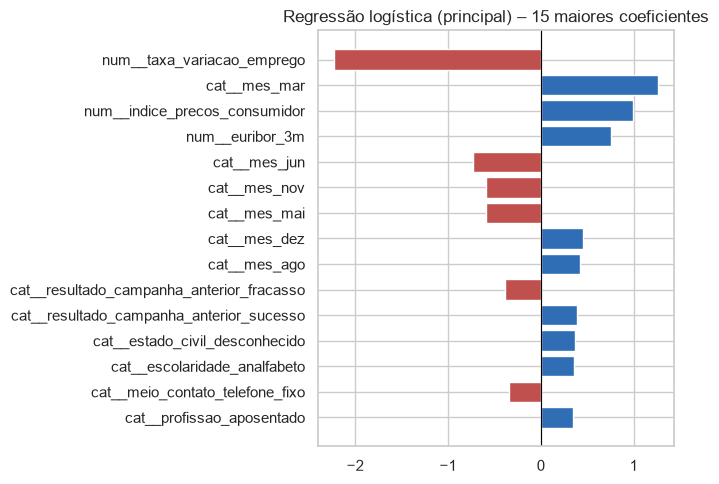

In [28]:
top15 = coefs.sort_values('|coef|', ascending=False).head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(top15['atributo'], top15['coef'], color=np.where(top15['coef'] > 0, '#2f6db5', '#c0504d'))
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Regressão logística (principal) – 15 maiores coeficientes')
plt.tight_layout(); plt.savefig('figuras/fig9_coef.png', dpi=150); plt.show()

## 5. Fechamento
- O cenário completo tem números bem melhores, mas isso vem quase todo da `duracao_ligacao_seg`, que não existe na hora de decidir quem ligar. É desempenho que não se repetiria em produção.
- No cenário principal, a escolha do modelo é feita pelo F1 da classe `sim` (teste e validação cruzada). A discussão completa, junto com a análise dos erros, está no relatório.